In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"C:\Users\mahek\Desktop\Hack-O-Week\feb\2016-building-energy-benchmarking.csv")
print(df.shape)
print(df.columns)

(3376, 46)
Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
    

In [ ]:
cols = [
    "PropertyName",
    "PrimaryPropertyType",
    "Electricity(kWh)",
    "NaturalGas(kBtu)",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]
df = df[cols]
df = df.dropna()


In [ ]:
df.rename(columns={
    "PropertyName": "building",
    "PrimaryPropertyType": "building_type"
}, inplace=True)

In [ ]:

df["site_energy_kwh"] = df["SiteEnergyUse(kBtu)"] * 0.293

df["carbon_kg"] = df["TotalGHGEmissions"] * 1000


In [6]:
campus = df.groupby("building_type").agg({
    "Electricity(kWh)": "sum",
    "site_energy_kwh": "sum",
    "carbon_kg": "sum"
}).reset_index()


In [ ]:
RENEWABLE_RATIO = 0.30

campus["renewable_kwh"] = campus["site_energy_kwh"] * RENEWABLE_RATIO
campus["carbon_saved_kg"] = campus["renewable_kwh"] * 0.82
campus["efficiency_score"] = (
    campus["renewable_kwh"] / campus["site_energy_kwh"]
) * 100


In [ ]:
from sklearn.linear_model import LinearRegression
campus["index"] = np.arange(len(campus))
X = campus[["index"]]
y = campus["site_energy_kwh"]
reg = LinearRegression()
reg.fit(X, y)
campus["regression_pred"] = reg.predict(X)

In [ ]:
campus["smoothed_energy"] = (
    campus["site_energy_kwh"]
    .rolling(window=3, min_periods=1)
    .mean()
)

In [ ]:
campus["ensemble_energy"] = (
    campus["regression_pred"] + campus["smoothed_energy"]
) / 2

In [ ]:
TOTAL_ENERGY = campus["site_energy_kwh"].sum()
TOTAL_CARBON = campus["carbon_kg"].sum()
TOTAL_CARBON_SAVED = campus["carbon_saved_kg"].sum()
print("Total Campus Energy (kWh):", round(TOTAL_ENERGY, 2))
print("Total Carbon Emissions (kg):", round(TOTAL_CARBON, 2))
print("Total Carbon Saved (kg):", round(TOTAL_CARBON_SAVED, 2))


Total Campus Energy (kWh): 5336279679.27
Total Carbon Emissions (kg): 403110610.0
Total Carbon Saved (kg): 1312724801.1


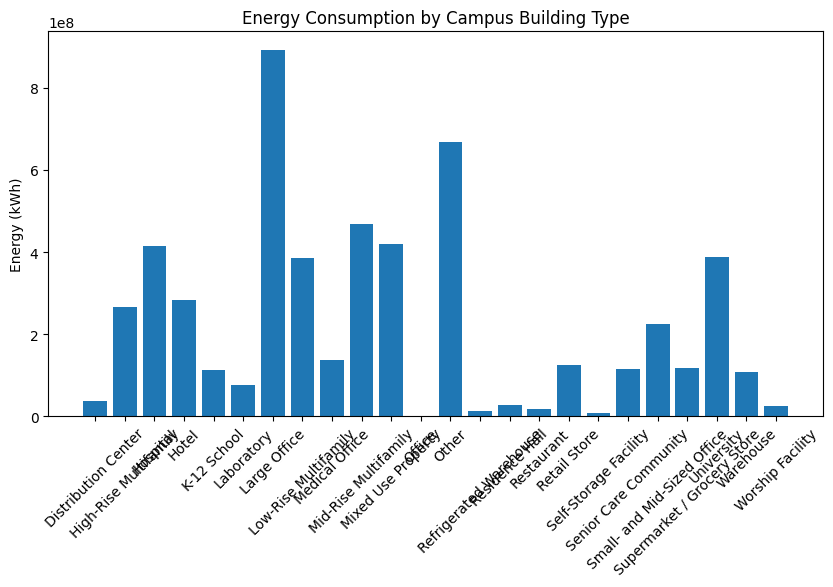

In [12]:
plt.figure(figsize=(10,5))
plt.bar(campus["building_type"], campus["site_energy_kwh"])
plt.xticks(rotation=45)
plt.title("Energy Consumption by Campus Building Type")
plt.ylabel("Energy (kWh)")
plt.show()


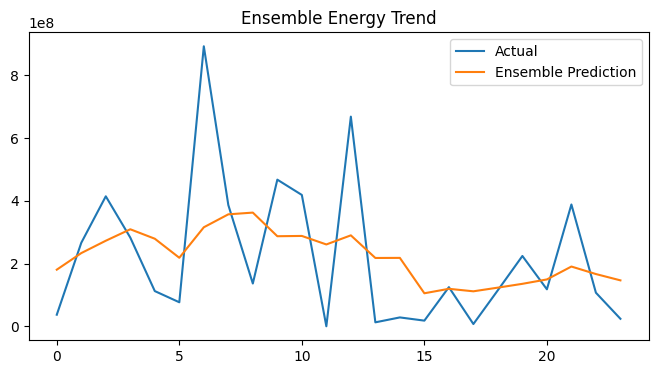

In [13]:
plt.figure(figsize=(8,4))
plt.plot(campus["site_energy_kwh"], label="Actual")
plt.plot(campus["ensemble_energy"], label="Ensemble Prediction")
plt.legend()
plt.title("Ensemble Energy Trend")
plt.show()


In [14]:
campus.to_csv("ps10_campus_sustainability_final.csv", index=False)


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


In [16]:
r2_reg = r2_score(
    campus["site_energy_kwh"],
    campus["regression_pred"]
)

mae_reg = mean_absolute_error(
    campus["site_energy_kwh"],
    campus["regression_pred"]
)

rmse_reg = np.sqrt(mean_squared_error(
    campus["site_energy_kwh"],
    campus["regression_pred"]
))

print("Regression R²:", round(r2_reg, 3))
print("Regression MAE:", round(mae_reg, 2))
print("Regression RMSE:", round(rmse_reg, 2))


Regression R²: 0.074
Regression MAE: 169267125.55
Regression RMSE: 217118992.82
